# Conformer Model - Dataset m01
## 5-Class Speech Emotion Recognition

**Classes:** angry, disgust, fear, sad, neutral

**Dataset:** data_features_m01.csv

In [28]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import (Input, Dense, LayerNormalization, Dropout, 
                                   MultiHeadAttention, Conv1D, GlobalAveragePooling1D)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [29]:
# Load and explore dataset m01
dataset_path = '../dataset step 3/data_features_m01.csv'
data = pd.read_csv(dataset_path)

print(f"Dataset shape: {data.shape}")
print(f"\nColumns: {data.columns.tolist()}")
print(f"\nLabel distribution:")
print(data['label'].value_counts())
print(f"\nFirst few rows:")
data.head()

Dataset shape: (4320, 41)

Columns: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', 'label']

Label distribution:
label
sad        960
angry      960
fear       960
disgust    960
neutral    480
Name: count, dtype: int64

First few rows:


,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,label
0,-694.231506,50.040554,0.552267,14.545629,3.444762,-2.469327,-3.988867,-10.599405,-7.204890,1.954130,...,-2.288055,-2.360345,-0.095407,-4.405079,-1.800773,-4.493698,-1.277828,-2.576992,-3.165682,neutral
1,-469.682239,24.812481,4.376637,7.737900,1.735599,-2.431461,-5.189324,-9.094118,-6.905061,-2.111880,...,-1.699113,-1.246151,-1.377645,-2.539707,-1.537789,-2.144637,-1.753057,-1.661558,-2.266360,neutral
2,-693.813782,49.947689,0.508969,14.515021,3.444183,-2.481389,-3.980087,-10.598415,-7.220357,1.961650,...,-2.284818,-2.349918,-0.105782,-4.420014,-1.789514,-4.494311,-1.271694,-2.580723,-3.176553,neutral
3,-706.712158,47.825089,-0.674069,14.761738,2.468847,-4.197237,-6.947045,-11.992122,-5.492224,1.690096,...,-1.509774,-1.567980,-2.817490,-4.761173,-2.271072,-4.018981,-0.811464,-4.686175,-2.178420,neutral
4,-706.450291,51.669993,-0.672582,11.109251,0.728495,-3.095116,-7.086010,-14.615463,-9.870567,2.474204,...,-1.227616,-1.464897,1.881643,-2.496609,-1.416349,-3.118476,0.819272,-2.767044,-3.644269,neutral


In [30]:
# Data preprocessing
from sklearn.utils import resample

target_classes = ['angry', 'disgust', 'fear', 'sad', 'neutral']
data_filtered = data[data['label'].isin(target_classes)].copy()

# Oversample neutral (480 → 960) to match other classes
neutral_df = data_filtered[data_filtered['label'] == 'neutral']
other_df   = data_filtered[data_filtered['label'] != 'neutral']
neutral_upsampled = resample(neutral_df, n_samples=960, random_state=42)
data_balanced = pd.concat([other_df, neutral_upsampled]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Balanced dataset shape: {data_balanced.shape}")
print(f"\nClass distribution after balancing:")
for label, count in data_balanced['label'].value_counts().items():
    print(f"   {label}: {count} samples")

X = data_balanced.drop('label', axis=1).values
y = data_balanced['label'].values

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"\nClasses: {label_encoder.classes_}")
print(f"Number of classes: {len(label_encoder.classes_)}")

Balanced dataset shape: (4800, 41)

Class distribution after balancing:
   fear: 960 samples
   sad: 960 samples
   disgust: 960 samples
   angry: 960 samples
   neutral: 960 samples

Classes: ['angry' 'disgust' 'fear' 'neutral' 'sad']
Number of classes: 5


In [31]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Train samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape for model input (samples, timesteps, features)
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print(f"Reshaped train data: {X_train_reshaped.shape}")
print(f"Reshaped test data: {X_test_reshaped.shape}")

# Convert labels to categorical
y_train_cat = to_categorical(y_train, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

print(f"Categorical labels shape: {y_train_cat.shape}")

Train samples: 3840
Test samples: 960
Reshaped train data: (3840, 40, 1)
Reshaped test data: (960, 40, 1)
Categorical labels shape: (3840, 5)


In [32]:
# Create Conformer model
def create_conformer_block(embed_dim, num_heads, ff_dim, rate=0.1):
    def conformer_block(inputs):
        attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(inputs, inputs)
        attn_output = Dropout(rate)(attn_output)
        out1 = LayerNormalization(epsilon=1e-6)(inputs + attn_output)
        
        conv_output = Conv1D(filters=embed_dim, kernel_size=3, padding="same", activation="relu")(out1)
        conv_output = Dropout(rate)(conv_output)
        out2 = LayerNormalization(epsilon=1e-6)(out1 + conv_output)
        
        ffn_output = Dense(ff_dim, activation="relu")(out2)
        ffn_output = Dense(embed_dim)(ffn_output)
        ffn_output = Dropout(rate)(ffn_output)
        
        return LayerNormalization(epsilon=1e-6)(out2 + ffn_output)
    
    return conformer_block

def create_conformer_model(input_shape, num_classes=5, embed_dim=64, num_heads=4, ff_dim=128):
    inputs = Input(shape=input_shape)
    
    x = Dense(embed_dim)(inputs)
    
    conformer_block = create_conformer_block(embed_dim, num_heads, ff_dim)
    x = conformer_block(x)
    x = conformer_block(x)
    
    x = GlobalAveragePooling1D()(x)
    
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs, outputs, name='Conformer_EmotionRecognition')
    return model

input_shape = (X_train_reshaped.shape[1], X_train_reshaped.shape[2])
model = create_conformer_model(input_shape)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Conformer model created and compiled!")
model.summary()

Conformer model created and compiled!
Model: "Conformer_EmotionRecognition"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_4 (InputLayer)        [(None, 40, 1)]              0         []                            
                                                                                                  
 dense_24 (Dense)            (None, 40, 64)               128       ['input_4[0][0]']             
                                                                                                  
 multi_head_attention_6 (Mu  (None, 40, 64)               66368     ['dense_24[0][0]',            
 ltiHeadAttention)                                                   'dense_24[0][0]']            
                                                                                                  
 dropout_24 (Dropout)        (Non

In [33]:
# Training
print("Starting training...")

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=50,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    'best_conformer_m01.h5',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

history = model.fit(
    X_train_reshaped, y_train_cat,
    validation_data=(X_test_reshaped, y_test_cat),
    epochs=150,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr, model_checkpoint],
    verbose=1
)

print("Training completed!")

Starting training...
Epoch 1/150


2026-06-10 17:02:47.092848: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


120/120 [==============================] - ETA: 0s - loss: 1.8598 - accuracy: 0.2089
Epoch 1: val_accuracy improved from -inf to 0.21458, saving model to best_conformer_m01.h5
120/120 [==============================] - 12s 80ms/step - loss: 1.8598 - accuracy: 0.2089 - val_loss: 1.6416 - val_accuracy: 0.2146 - lr: 0.0010
Epoch 2/150
120/120 [==============================] - ETA: 0s - loss: 1.7441 - accuracy: 0.2148
Epoch 2: val_accuracy improved from 0.21458 to 0.26771, saving model to best_conformer_m01.h5
120/120 [==============================] - 7s 58ms/step - loss: 1.7441 - accuracy: 0.2148 - val_loss: 1.5905 - val_accuracy: 0.2677 - lr: 0.0010
Epoch 3/150
120/120 [==============================] - ETA: 0s - loss: 1.6918 - accuracy: 0.2323
Epoch 3: val_accuracy did not improve from 0.26771
120/120 [==============================] - 7s 54ms/step - loss: 1.6918 - accuracy: 0.2323 - val_loss: 1.6940 - val_accuracy: 0.2344 - lr: 0.0010
Epoch 4/150
119/120 [============================

In [25]:
# Evaluation and Results
print("CONFORMER MODEL EVALUATION - Dataset m01")
print("=" * 60)

# Predictions
y_pred_prob = model.predict(X_test_reshaped, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# Test accuracy
test_loss, test_accuracy = model.evaluate(X_test_reshaped, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Classification Report
print(f"\nCLASSIFICATION REPORT:")
print("-" * 50)
class_names = label_encoder.classes_
report = classification_report(y_test, y_pred, target_names=class_names, digits=4)
print(report)

# Cohen's Kappa
kappa = cohen_kappa_score(y_test, y_pred)
print(f"\nCohen's Kappa Score: {kappa:.4f}")

# Training Summary
epochs_trained = len(history.history['accuracy'])
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"\nTRAINING SUMMARY:")
print("-" * 50)
print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Epochs Trained: {epochs_trained}")

CONFORMER MODEL EVALUATION - Dataset m01
Test Accuracy: 0.4745
Test Loss: 1.3191

CLASSIFICATION REPORT:
--------------------------------------------------
              precision    recall  f1-score   support

       angry     0.5793    0.4948    0.5337       192
     disgust     0.4335    0.4583    0.4456       192
        fear     0.5405    0.5208    0.5305       192
     neutral     0.3422    0.8021    0.4798        96
         sad     0.5747    0.2604    0.3584       192

    accuracy                         0.4745       864
   macro avg     0.4940    0.5073    0.4696       864
weighted avg     0.5109    0.4745    0.4685       864


Cohen's Kappa Score: 0.3486

TRAINING SUMMARY:
--------------------------------------------------
Final Training Accuracy: 0.5084
Final Validation Accuracy: 0.4745
Epochs Trained: 150


In [26]:
# Save model
import os
save_dir = "/Users/giangmytien/Desktop/KLTN/Demo app/models conformer"
os.makedirs(save_dir, exist_ok=True)

model.save(os.path.join(save_dir, "best_conformer_m01.h5"))
print("Model saved to:", save_dir)

Model saved to: /Users/giangmytien/Desktop/KLTN/Demo app/models conformer


In [27]:
import joblib
joblib.dump(scaler, "/Users/giangmytien/Desktop/KLTN/Demo app/models conformer/scaler.pkl")
joblib.dump(label_encoder, "/Users/giangmytien/Desktop/KLTN/Demo app/models conformer/label_encoder.pkl")
print("Saved! Classes:", list(label_encoder.classes_))
print("Scaler mean[0]:", round(scaler.mean_[0], 2))

Saved! Classes: ['angry', 'disgust', 'fear', 'neutral', 'sad']
Scaler mean[0]: -528.12



CONFUSION MATRIX:
--------------------------------------------------
Predicted ->
True    angry     disgust   fear      neutral   sad       
angry   136       38        11        4         3         
disgust 16        130       27        5         14        
fear    18        25        132       6         11        
neutral 2         17        6         44        27        
sad     12        29        32        23        96        


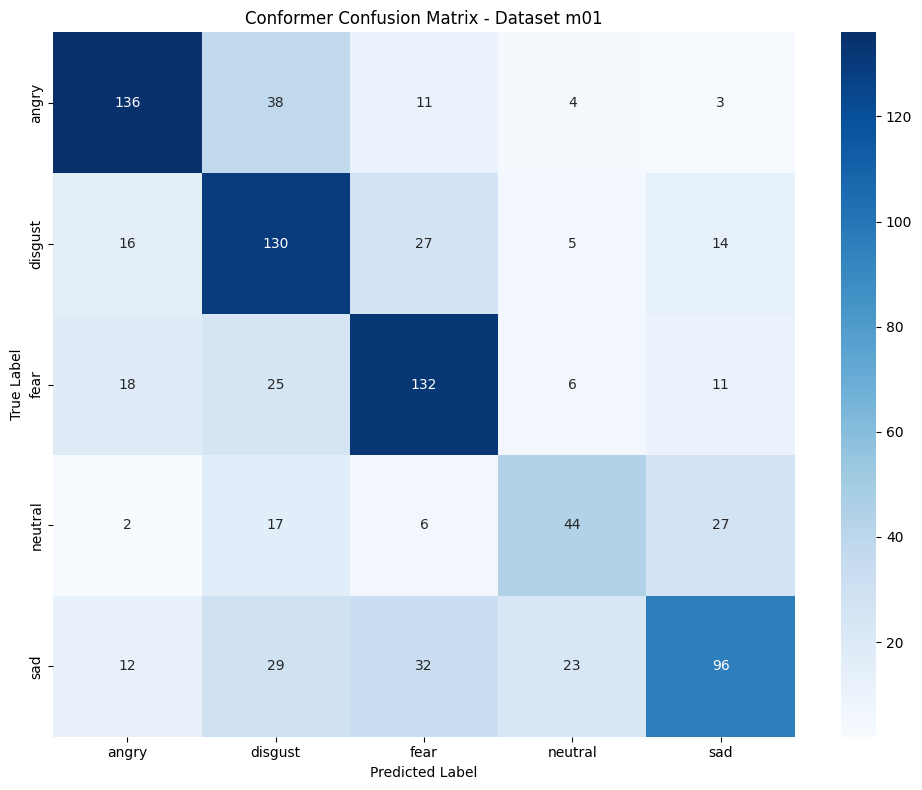

In [8]:
# Confusion Matrix
print(f"\nCONFUSION MATRIX:")
print("-" * 50)
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix in text format
print("Predicted ->")
print(f"{'True':<8}", end="")
for class_name in class_names:
    print(f"{class_name:<10}", end="")
print()

for i, class_name in enumerate(class_names):
    print(f"{class_name:<8}", end="")
    for j in range(len(class_names)):
        print(f"{cm[i,j]:<10}", end="")
    print()

# Visualize Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Conformer Confusion Matrix - Dataset m01')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

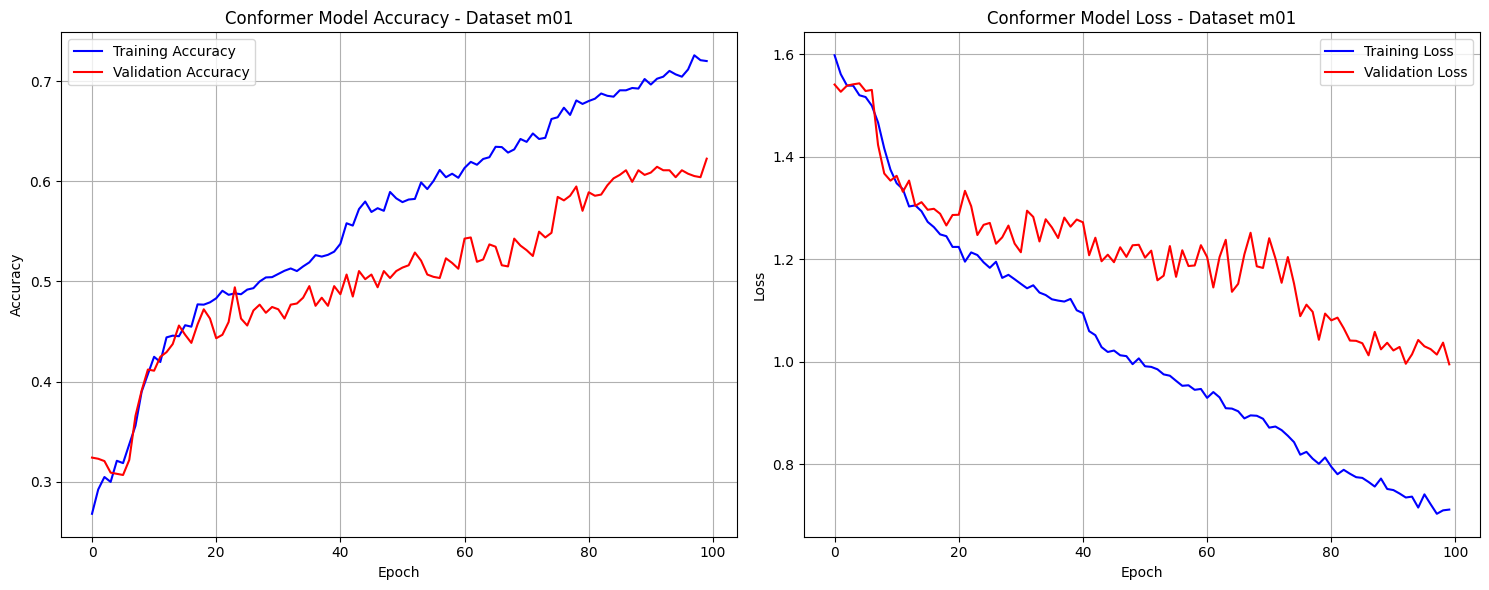

Training history plots generated!


In [9]:
# Plot Training History
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
ax1.set_title('Conformer Model Accuracy - Dataset m01')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Validation Loss', color='red')
ax2.set_title('Conformer Model Loss - Dataset m01')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("Training history plots generated!")

In [ ]:
# Final summary
print(f"\nFINAL RESULTS SUMMARY - Conformer m01")
print("=" * 60)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"Epochs Trained: {epochs_trained}")
print(f"Dataset: data_features_m01.csv")
print(f"Classes: {', '.join(class_names)}")


FINAL RESULTS SUMMARY - Conformer m01
Test Accuracy: 0.6227
Cohen's Kappa: 0.5214
Epochs Trained: 100
Dataset: data_features_m01.csv
Classes: angry, disgust, fear, neutral, sad


: 